In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
# from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau
import cv2
import os

In [ ]:
import os

# Check if the directory exists and list its contents
def check_directory_contents(directory):
    if os.path.exists(directory):
        print(f"Contents of {directory}:")
        for root, dirs, files in os.walk(directory):
            for file in files:
                print(os.path.join(root, file))
    else:
        print(f"Directory {directory} does not exist.")

check_directory_contents('/content/drive/My Drive/dataset/dataset1')

Contents of /content/drive/My Drive/dataset/dataset1:
/content/drive/My Drive/dataset/dataset1/test/0/test_108.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_129.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_139.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_119.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_111.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_134.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_116.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_127.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_120.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_104.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_142.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_123.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_141.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_103.jpg
/content/drive/My Drive/dataset/dataset1/test/0/test_132.jpg
/content/drive/My Drive/dataset

In [ ]:
import os
import cv2
import numpy as np

# Constants
img_size = 150
labels = ['PNEUMONIA', 'NORMAL']

def load_and_preprocess_data(data_dir):
    """
    Loads and preprocesses images from a specified directory.

    Args:
        data_dir (str): Directory path containing subdirectories for each label.

    Returns:
        np.array: Array of preprocessed images.
        np.array: Array of labels corresponding to each image.
    """
    images = []
    labels_list = []

    for label in labels:
        # Construct the path for the current label's directory
        path = os.path.join(data_dir, label)

        # Get the numeric class index for the current label
        class_num = labels.index(label)

        # Check if the directory exists
        if not os.path.exists(path):
            print(f"Directory not found: {path}")
            continue

        # Process each image file in the directory
        for img_file in os.listdir(path):
            img_path = os.path.join(path, img_file)

            try:
                # Read the image as grayscale
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img_arr is None:
                    print(f"Image not loaded correctly: {img_path}")
                    continue

                # Resize the image
                resized_arr = cv2.resize(img_arr, (img_size, img_size))

                # Append the processed image and its label
                images.append(resized_arr)
                labels_list.append(class_num)

            except Exception as e:
                # Print any error that occurs during image processing
                print(f"Error processing image {img_file}: {e}")

    # Convert lists to numpy arrays and return
    return np.array(images), np.array(labels_list)


In [ ]:
x_train, y_train = load_and_preprocess_data('/content/drive/My Drive/dataset/dataset1/train')
x_test, y_test = load_and_preprocess_data('/content/drive/My Drive/dataset/dataset1/test')
x_val, y_val = load_and_preprocess_data('/content/drive/My Drive/dataset/dataset1/val')


In [ ]:
print(x_train,y_train)

[[[ 49  53  59 ...  19   6   6]
  [ 51  56  62 ...  25   9   8]
  [ 54  60  66 ...  34  18   5]
  ...
  [ 20  16  29 ...  25  28  30]
  [ 21  15  28 ...  26  28  29]
  [ 19  12  26 ...  27  29  29]]

 [[  2  18  33 ...   1   0  11]
  [  2  18  33 ...   1   0  11]
  [  2  17  32 ...   1   0  11]
  ...
  [  0   0   0 ...  20   1   0]
  [  0   0   0 ...  20   1   0]
  [  0   0   0 ...  20   1   0]]

 [[ 34  26  18 ...  28  20  10]
  [ 33  34  34 ...  35  34  16]
  [ 22  26  30 ...  48  46  26]
  ...
  [ 11  12  13 ...   4   5   4]
  [ 14  13  12 ...   4   5   4]
  [ 17  14  12 ...   4   5   4]]

 ...

 [[ 49  62  72 ... 145 141 181]
  [ 48  60  69 ... 140 148 186]
  [ 47  58  68 ... 137 163 172]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[ 77  85  90 ...  63  63  64]
  [ 79  86  90 ...  69  69  69]
  [ 72  81  89 ...  70  69  68]
  ...
  [  3   1   0 ...   0   0   0]
  [  3   2   0 ...   0   0   0]
  [  0   2   0 ...   0   0  

In [ ]:
import pickle

# Save using pickle (supports any Python object)
with open('/content/drive/MyDrive/dataset1.pkl', 'wb') as f:
    pickle.dump((x_train, y_train, x_test, y_test, x_val, y_val), f)
    f.flush()  # Force writing
    os.fsync(f.fileno())  # Ensure data is saved


In [ ]:
import pickle
with open('/content/drive/MyDrive/dataset1.pkl', 'rb') as f:
    x_train, y_train, x_test, y_test, x_val, y_val = pickle.load(f)


In [ ]:
print(x_train,y_train)

[[[ 49  53  59 ...  19   6   6]
  [ 51  56  62 ...  25   9   8]
  [ 54  60  66 ...  34  18   5]
  ...
  [ 20  16  29 ...  25  28  30]
  [ 21  15  28 ...  26  28  29]
  [ 19  12  26 ...  27  29  29]]

 [[  2  18  33 ...   1   0  11]
  [  2  18  33 ...   1   0  11]
  [  2  17  32 ...   1   0  11]
  ...
  [  0   0   0 ...  20   1   0]
  [  0   0   0 ...  20   1   0]
  [  0   0   0 ...  20   1   0]]

 [[ 34  26  18 ...  28  20  10]
  [ 33  34  34 ...  35  34  16]
  [ 22  26  30 ...  48  46  26]
  ...
  [ 11  12  13 ...   4   5   4]
  [ 14  13  12 ...   4   5   4]
  [ 17  14  12 ...   4   5   4]]

 ...

 [[ 49  62  72 ... 145 141 181]
  [ 48  60  69 ... 140 148 186]
  [ 47  58  68 ... 137 163 172]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[ 77  85  90 ...  63  63  64]
  [ 79  86  90 ...  69  69  69]
  [ 72  81  89 ...  70  69  68]
  ...
  [  3   1   0 ...   0   0   0]
  [  3   2   0 ...   0   0   0]
  [  0   2   0 ...   0   0  

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(4112, 150, 150)
(4112,)
(589, 150, 150)
(589,)


In [ ]:
y_train

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
# from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau
import cv2
import os

In [ ]:
# Visualization
labels_list = ['Pneumonia' if label == 0 else 'Normal' for label in y_train]


In [ ]:
print(len(labels_list))

4112


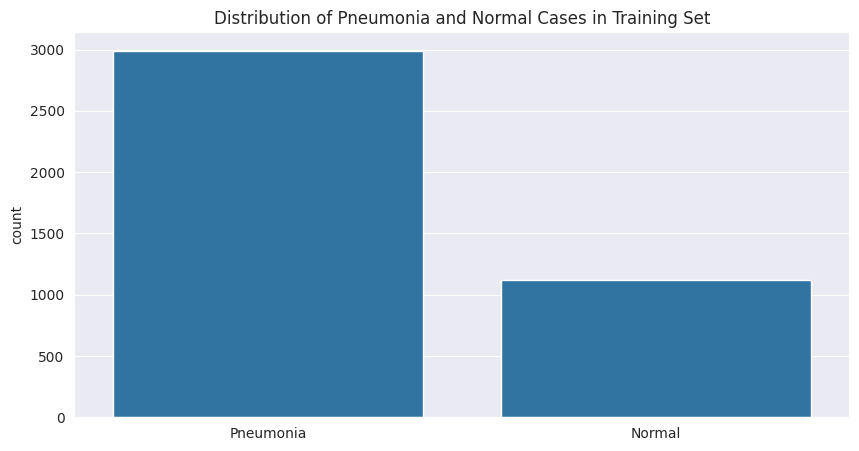

In [ ]:
# Set plot style
plt.figure(figsize=(10, 5))
sns.set_style('darkgrid')
# # Create a count plot to visualize the distribution of the classes in the training set

sns.countplot(x=labels_list)
plt.title('Distribution of Pneumonia and Normal Cases in Training Set')
plt.show()

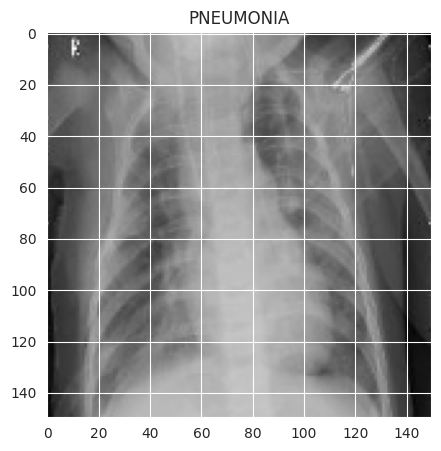

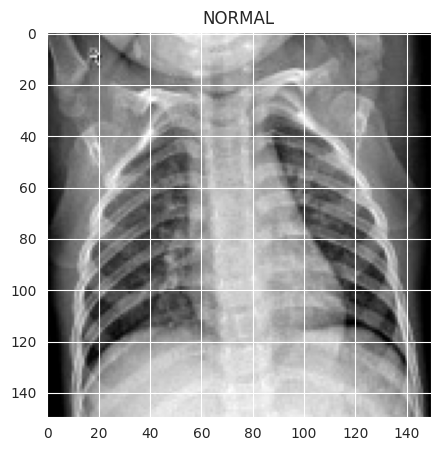

In [ ]:
# Plot the first image in the training set
plt.figure(figsize=(5, 5))
plt.imshow(x_train[0], cmap='gray')
plt.title(labels[y_train[0]])
plt.show()

# Plot the last image in the training set
plt.figure(figsize=(5, 5))
plt.imshow(x_train[-1], cmap='gray')
plt.title(labels[y_train[-1]])
plt.show()

In [ ]:
# Normalize the data
x_train = np.array(x_train) / 255
x_val = np.array(x_val) / 255
x_test = np.array(x_test) / 255

In [ ]:
# resize data for deep learning
x_train = x_train.reshape(-1, img_size, img_size, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, img_size, img_size, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

In [ ]:
# With data augmentation to prevent overfitting and handling the imbalance in dataset

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(x_train)

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping,  ModelCheckpoint
import numpy as np

In [ ]:
modelCNN = load_model('cnn_90_05_april.h5')  # CNN model

In [ ]:
# Make predictions using the model
predictCNN = modelCNN.predict(x_test)

# Convert probabilities to class labels
predictCNN = (predictCNN > 0.5).astype(int)  # Assuming a binary classification

# Reshape predictions if necessary
predictCNN = predictCNN.reshape(1, -1)[0]

# Display the first 15 predictions
print(predictCNN[:15])


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

# Assuming y_test contains the true labels
accuracy = accuracy_score(y_test, predictCNN)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 96.43%


In [ ]:
num_zeros = np.sum(predictCNN == 0)
num_ones = np.sum(predictCNN == 1)

print(f"Number of 0s: {num_zeros}")
print(f"Number of 1s: {num_ones}")

Number of 0s: 427
Number of 1s: 162
